# Module 4: Machine Learning Fundamentals

**Beginner Track — Generative AI and Data Science Pathway**

This notebook covers the foundational concepts of Machine Learning: what it is, and the three core paradigms — Supervised, Unsupervised, and Reinforcement Learning — each illustrated with a small working example rather than definitions alone.

**Reference:** Microsoft's open-source curriculum — [ML-For-Beginners](https://github.com/microsoft/ML-For-Beginners) — is used as the conceptual reference for this module's structure and terminology.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, adjusted_rand_score, confusion_matrix

np.random.seed(42)


## 1. What is Machine Learning?

**Machine Learning (ML)** is a branch of artificial intelligence in which a system learns patterns from data and improves its performance on a task without being explicitly programmed with rules for that task.

The classical definition, from Tom Mitchell (1997):

> "A computer program is said to learn from experience `E` with respect to some class of tasks `T` and performance measure `P`, if its performance at tasks in `T`, as measured by `P`, improves with experience `E`."

In practice, this means: instead of writing hand-coded rules (`if petal_length > 2.5 and petal_width < 1: ...`), we give the algorithm examples, and it discovers the rules — or more precisely, a function — that maps inputs to outputs on its own.

ML is generally split into three paradigms, based on what kind of "experience" (data and feedback) the algorithm learns from:

| Paradigm | What it learns from | Goal |
|---|---|---|
| **Supervised Learning** | Labeled examples (input + correct answer) | Predict labels for new, unseen inputs |
| **Unsupervised Learning** | Unlabeled data (input only) | Discover hidden structure or groupings |
| **Reinforcement Learning** | Trial-and-error interaction + reward signal | Learn a strategy that maximizes cumulative reward |

Each is demonstrated below with a small working example.


## 2. Supervised Learning

**Definition:** the algorithm is trained on a dataset where every input `x` is paired with the correct output `y` (a "label"). The goal is to learn a mapping `f(x) → y` that generalizes to new, unseen inputs.

- If `y` is a category (e.g., species of flower), it's a **classification** problem.
- If `y` is a continuous number (e.g., house price), it's a **regression** problem.

**Demo:** classifying iris flower species from their measurements — the same dataset used in Module 2, now used to demonstrate the supervised paradigm specifically: the model is given labeled examples (measurements *and* the correct species) during training.

In [2]:
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# Split into labeled training data and a held-out labeled test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training examples (with labels): {X_train.shape[0]}")
print(f"Test examples (labels held out for evaluation): {X_test.shape[0]}")

# Train a simple supervised classifier
clf = KNeighborsClassifier(n_neighbors=5)
clf.fit(X_train, y_train)   # <-- learns from (input, correct answer) pairs

predictions = clf.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"\nTest accuracy: {accuracy:.2%}")


Training examples (with labels): 105
Test examples (labels held out for evaluation): 45

Test accuracy: 97.78%


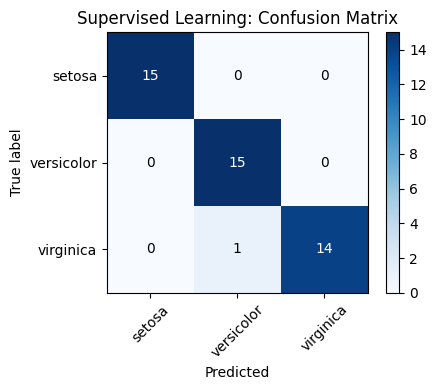

In [3]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(class_names, rotation=45)
ax.set_yticks(range(3)); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True label")
ax.set_title("Supervised Learning: Confusion Matrix")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()


## 3. Unsupervised Learning

**Definition:** the algorithm is given data with **no labels** — only the inputs `x`, with no "correct answer" attached. Instead of predicting a known target, the goal is to discover structure that's already latent in the data: groupings, patterns, or a simpler representation.

Common tasks: **clustering** (grouping similar points together), dimensionality reduction, and anomaly detection.

**Demo:** clustering the same iris measurements — but this time **without showing the algorithm any species labels at all**. It only sees the four measurements and has to find groups on its own. We then compare the discovered groups against the true species labels (which the algorithm never saw) purely to evaluate how well it did — the model itself has no access to `y` during training.

In [4]:
# Note: only X is passed in — no y. This is the core distinction from supervised learning above.
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
cluster_assignments = kmeans.fit_predict(X)   # <-- learns from inputs alone, no labels

# We only use the true labels afterward, to SCORE how good the discovered
# clusters are -- the clustering algorithm itself never saw them.
ari = adjusted_rand_score(y, cluster_assignments)
print(f"Adjusted Rand Index vs. true species (evaluation only): {ari:.3f}")
print("(1.0 = perfect match to true groupings, 0.0 = random)")


Adjusted Rand Index vs. true species (evaluation only): 0.730
(1.0 = perfect match to true groupings, 0.0 = random)


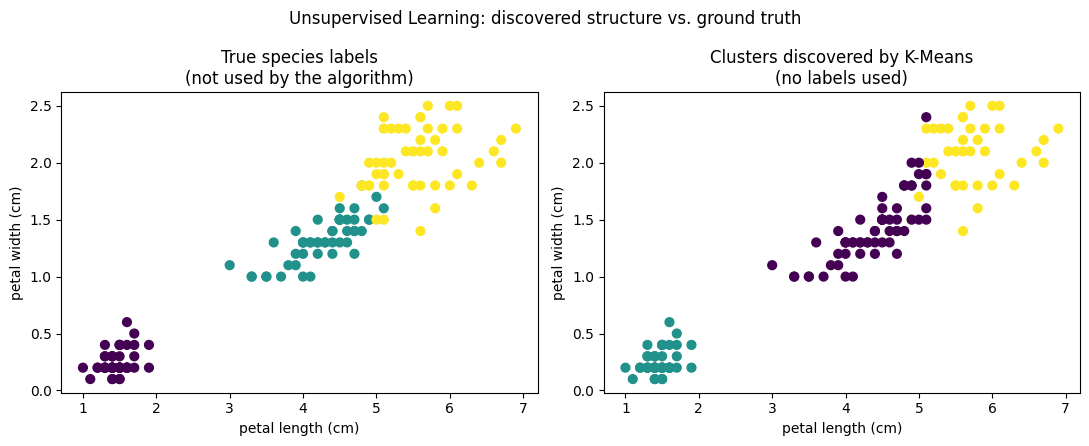

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

scatter1 = axes[0].scatter(X[:, 2], X[:, 3], c=y, cmap='viridis', s=40)
axes[0].set_title("True species labels\n(not used by the algorithm)")
axes[0].set_xlabel(feature_names[2]); axes[0].set_ylabel(feature_names[3])

scatter2 = axes[1].scatter(X[:, 2], X[:, 3], c=cluster_assignments, cmap='viridis', s=40)
axes[1].set_title("Clusters discovered by K-Means\n(no labels used)")
axes[1].set_xlabel(feature_names[2]); axes[1].set_ylabel(feature_names[3])

plt.suptitle("Unsupervised Learning: discovered structure vs. ground truth")
plt.tight_layout()
plt.show()


## 4. Reinforcement Learning

**Definition:** an **agent** interacts with an **environment** over time. At each step it takes an **action**, receives a **reward**, and updates its strategy to maximize *cumulative* reward — there's no fixed labeled dataset; the "training data" is generated by the agent's own trial-and-error experience.

Key ingredients: agent, environment, action, reward, and the **exploration vs. exploitation trade-off** — try new actions to discover what's rewarding (explore), or stick with what's worked so far (exploit)?

**Demo:** a classic minimal RL problem — the **multi-armed bandit**. Imagine 5 slot machines, each with a different (hidden, unknown) probability of paying out. The agent doesn't know these probabilities in advance — it only learns by pulling arms and observing rewards, using an **epsilon-greedy** strategy: mostly pick the best arm found so far, but occasionally (with probability `epsilon`) try a random one to keep exploring.

In [6]:
# Hidden reward probabilities the agent must discover through interaction
true_probs = [0.2, 0.5, 0.3, 0.8, 0.4]
n_arms = len(true_probs)
n_steps = 1000
epsilon = 0.1  # 10% chance of exploring instead of exploiting

value_estimates = np.zeros(n_arms)   # the agent's running estimate of each arm's payout
pull_counts = np.zeros(n_arms)
reward_history = []

for t in range(n_steps):
    if np.random.rand() < epsilon:
        arm = np.random.randint(n_arms)          # EXPLORE: try something new
    else:
        arm = np.argmax(value_estimates)          # EXPLOIT: use best known option

    reward = 1 if np.random.rand() < true_probs[arm] else 0   # environment's response

    pull_counts[arm] += 1
    # Incremental update: nudge the estimate toward the observed reward
    value_estimates[arm] += (reward - value_estimates[arm]) / pull_counts[arm]
    reward_history.append(reward)

print("True (hidden) probabilities:  ", true_probs)
print("Agent's learned estimates:    ", np.round(value_estimates, 2))
print(f"\nBest arm found by agent:  {np.argmax(value_estimates)}")
print(f"Actual best arm:           {np.argmax(true_probs)}")
print(f"\nAverage reward, first 100 steps: {np.mean(reward_history[:100]):.2f}")
print(f"Average reward, last 100 steps:  {np.mean(reward_history[-100:]):.2f}  (improvement = learning)")


True (hidden) probabilities:   [0.2, 0.5, 0.3, 0.8, 0.4]
Agent's learned estimates:     [0.22 0.4  0.21 0.81 0.52]

Best arm found by agent:  3
Actual best arm:           3

Average reward, first 100 steps: 0.69
Average reward, last 100 steps:  0.82  (improvement = learning)


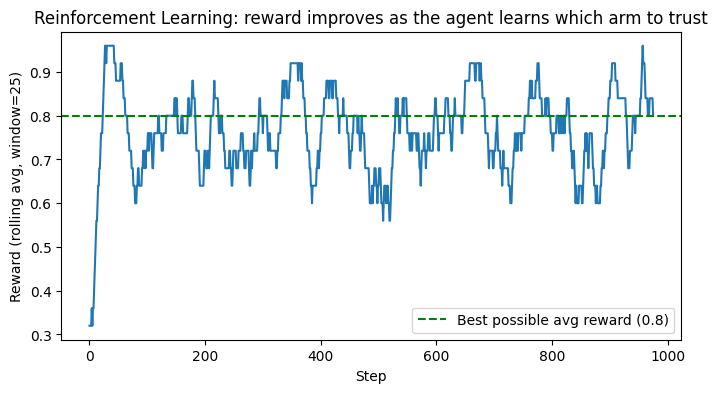

In [7]:
# Rolling average reward over time -- shows the agent's policy improving with experience
window = 25
rolling_avg = np.convolve(reward_history, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(rolling_avg)
plt.axhline(max(true_probs), color='green', linestyle='--', label=f'Best possible avg reward ({max(true_probs)})')
plt.xlabel("Step")
plt.ylabel(f"Reward (rolling avg, window={window})")
plt.title("Reinforcement Learning: reward improves as the agent learns which arm to trust")
plt.legend()
plt.show()


## 5. Summary

| | Supervised | Unsupervised | Reinforcement |
|---|---|---|---|
| **Feedback given** | Correct label for every example | None — inputs only | Reward signal after actions |
| **Goal** | Predict labels for new inputs | Find hidden structure | Maximize cumulative reward |
| **This notebook's demo** | KNN classifying iris species | K-Means clustering iris measurements | Epsilon-greedy multi-armed bandit |
| **Result (see output above)** | Test accuracy printed in §2 | Adjusted Rand Index printed in §3 | Best arm found vs. true best, printed in §4 |

**Reference:** [microsoft/ML-For-Beginners](https://github.com/microsoft/ML-For-Beginners) — a 12-week, 26-lesson open curriculum covering classic ML techniques using Scikit-learn, used here as the conceptual reference for this module's scope (definition of ML, and the three learning paradigms).
